In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/conbobietbay/phobert-student-feedback-clean/test_clean_PhoBERT.csv
/kaggle/input/datasets/conbobietbay/phobert-student-feedback-clean/dev_clean_PhoBERT.csv
/kaggle/input/datasets/conbobietbay/phobert-student-feedback-clean/train_clean_PhoBERT.csv
/kaggle/input/models/conbobietbay/models-phobert-gru/pytorch/default/1/models_PhoBERT_GRU/topic_model/best_phobert_gru_model.pth
/kaggle/input/models/conbobietbay/models-phobert-gru/pytorch/default/1/models_PhoBERT_GRU/topic_model/__huggingface_repos__.json
/kaggle/input/models/conbobietbay/models-phobert-gru/pytorch/default/1/models_PhoBERT_GRU/topic_model/best_phobert_gru_model_tokenizer/bpe.codes
/kaggle/input/models/conbobietbay/models-phobert-gru/pytorch/default/1/models_PhoBERT_GRU/topic_model/best_phobert_gru_model_tokenizer/tokenizer_config.json
/kaggle/input/models/conbobietbay/models-phobert-gru/pytorch/default/1/models_PhoBERT_GRU/topic_model/best_phobert_gru_model_tokenizer/vocab.txt
/kaggle/input/models/conb

SỬ DỤNG PYTHON 3.12 ĐỂ TEST PHOBERT + GRU

🚀 BẮT ĐẦU HỆ THỐNG ĐÁNH GIÁ (TESTING) PHOBERT + GRU...
🔍 Đang quét hệ thống file Kaggle...


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Đã nạp thành công PhoBERT+GRU lên: cuda

📥 Đang đọc dữ liệu Test...
🚀 Bắt đầu chấm điểm 3166 bài thi...


  0%|          | 0/3166 [00:00<?, ?it/s]


🏆 BÁO CÁO THÀNH TÍCH PHOBERT + GRU: CẢM XÚC
                precision    recall  f1-score   support

  Tiêu cực (0)       0.02      0.02      0.02      1409
Trung tính (1)       0.03      0.23      0.05       167
  Tích cực (2)       0.07      0.00      0.01      1590

      accuracy                           0.02      3166
     macro avg       0.04      0.08      0.02      3166
  weighted avg       0.05      0.02      0.01      3166


🏆 BÁO CÁO THÀNH TÍCH PHOBERT + GRU: CHỦ ĐỀ
                    precision    recall  f1-score   support

    Giảng viên (0)       0.16      0.04      0.07      2290
  Chương trình (1)       0.04      0.16      0.06       572
Cơ sở vật chất (2)       0.02      0.01      0.02       145
          Khác (3)       0.01      0.01      0.01       159

          accuracy                           0.06      3166
         macro avg       0.06      0.06      0.04      3166
      weighted avg       0.13      0.06      0.06      3166



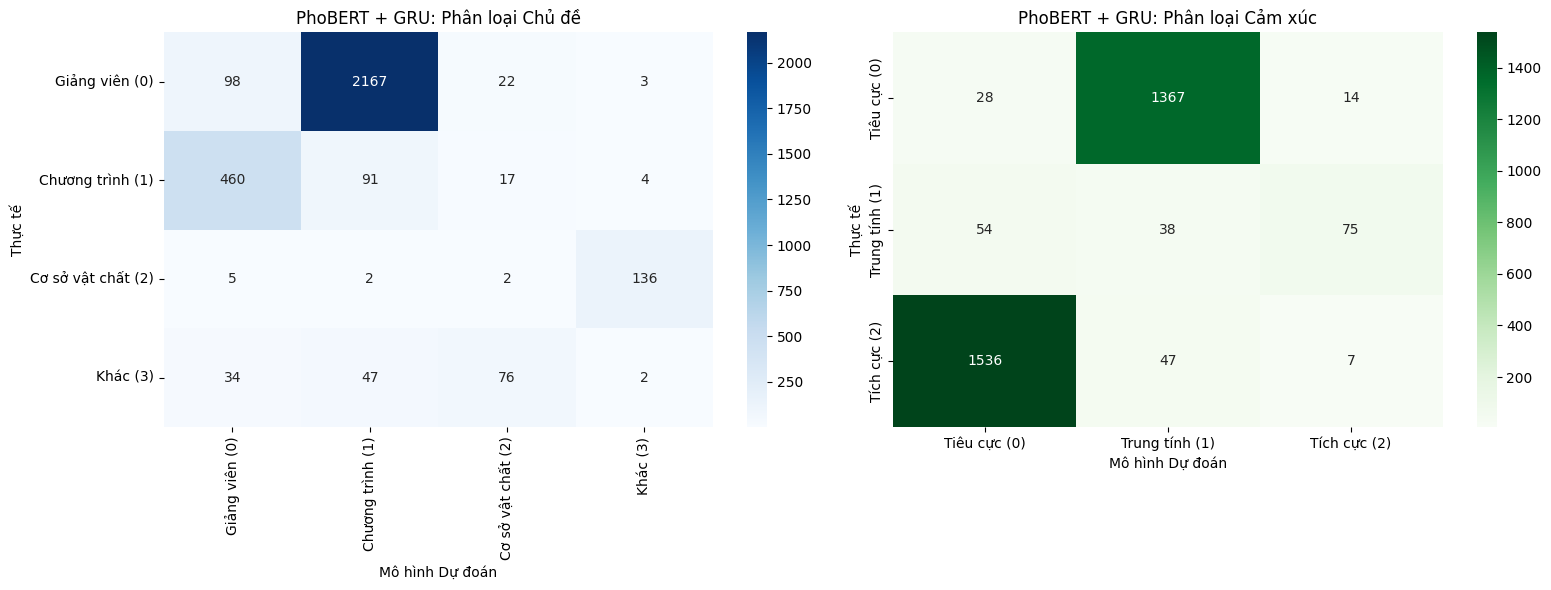

✅ Đã lưu ảnh đồ thị vào mục Output của Kaggle!


In [2]:
import os
import pandas as pd
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("🚀 BẮT ĐẦU HỆ THỐNG ĐÁNH GIÁ (TESTING) PHOBERT + GRU...")

# ==========================================
# 1. QUÉT TÌM ĐƯỜNG DẪN TỰ ĐỘNG
# ==========================================
print("🔍 Đang quét hệ thống file Kaggle...")
test_path = None
senti_model_path = None
senti_tok_path = None
topic_model_path = None
topic_tok_path = None

for root, dirs, files in os.walk('/kaggle/input'):
    if 'test_clean_PhoBERT.csv' in files:
        test_path = os.path.join(root, 'test_clean_PhoBERT.csv')
    if 'best_phobert_gru_model.pth' in files:
        if 'sentiment' in root.lower():
            senti_model_path = os.path.join(root, 'best_phobert_gru_model.pth')
        elif 'topic' in root.lower():
            topic_model_path = os.path.join(root, 'best_phobert_gru_model.pth')
    if 'vocab.txt' in files:
        if 'sentiment' in root.lower() and 'tokenizer' in root.lower():
            senti_tok_path = root
        elif 'topic' in root.lower() and 'tokenizer' in root.lower():
            topic_tok_path = root

# ==========================================
# 2. ĐỊNH NGHĨA KIẾN TRÚC MÔ HÌNH (Đã sửa chuẩn 100% theo file train)
# ==========================================
class PhoBERT_GRU(nn.Module):
    def __init__(self, num_classes):
        super(PhoBERT_GRU, self).__init__()
        self.phobert = AutoModel.from_pretrained("vinai/phobert-base")
        self.gru = nn.GRU(input_size=self.phobert.config.hidden_size, 
                          hidden_size=256, 
                          num_layers=1, 
                          batch_first=True, 
                          bidirectional=True)
        
        # SỬA Ở ĐÂY: Đổi self.fc thành khối self.classifier giống hệt lúc train
        self.classifier = nn.Sequential(
            nn.Dropout(0.2), # (classifier.0) Tỉ lệ dropout này lúc Eval máy sẽ tự bỏ qua, nên để 0.2 hay 0.1 đều được
            nn.Linear(256 * 2, num_classes) # (classifier.1) Chính là cái lớp nó đang đòi trong thông báo lỗi!
        )
        
    def forward(self, input_ids, attention_mask):
        features = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = features.last_hidden_state 
        gru_out, _ = self.gru(sequence_output)
        last_hidden_state = gru_out[:, -1, :] 
        
        # SỬA Ở ĐÂY: Gọi self.classifier thay vì self.fc
        output = self.classifier(last_hidden_state)
        return output
# ==========================================
# 3. KHỞI TẠO MÔ HÌNH KAGGLE
# ==========================================
if not all([senti_model_path, topic_model_path, senti_tok_path, topic_tok_path, test_path]):
    print("❌ Lỗi: Không tìm thấy đủ file! Hãy kiểm tra lại Dataset đã up.")
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    tokenizer = AutoTokenizer.from_pretrained(senti_tok_path, local_files_only=True)
    
    model_sentiment = PhoBERT_GRU(num_classes=3).to(device)
    model_sentiment.load_state_dict(torch.load(senti_model_path, map_location=device))
    model_sentiment.eval()
    
    model_topic = PhoBERT_GRU(num_classes=4).to(device)
    model_topic.load_state_dict(torch.load(topic_model_path, map_location=device))
    model_topic.eval()
    print(f"✅ Đã nạp thành công PhoBERT+GRU lên: {device}")

# ==========================================
# 4. CHẠY DỰ ĐOÁN TRÊN TẬP TEST
# ==========================================
print("\n📥 Đang đọc dữ liệu Test...")
# Đọc tập test đã được làm sạch sẵn từ trước
df_test = pd.read_csv(test_path).dropna(subset=['clean_text_PhoBERT'])

texts = df_test['clean_text_PhoBERT'].tolist()
true_sentiments = df_test['sentiment'].tolist()
true_topics = df_test['topic'].tolist()

pred_sentiments = []
pred_topics = []

print(f"🚀 Bắt đầu chấm điểm {len(texts)} bài thi...")
for text in tqdm(texts):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=256).to(device)
    
    with torch.no_grad():
        out_s = model_sentiment(input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask'])
        out_t = model_topic(input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask'])
        
        pred_s_idx = torch.argmax(out_s, dim=1).item()
        pred_t_idx = torch.argmax(out_t, dim=1).item()
        
        pred_sentiments.append(pred_s_idx)
        pred_topics.append(pred_t_idx)

# ==========================================
# 5. XUẤT BÁO CÁO & VẼ MA TRẬN NHẦM LẪN
# ==========================================
sentiment_labels = ['Tiêu cực (0)', 'Trung tính (1)', 'Tích cực (2)']
topic_labels = ['Giảng viên (0)', 'Chương trình (1)', 'Cơ sở vật chất (2)', 'Khác (3)']

print("\n" + "="*45)
print("🏆 BÁO CÁO THÀNH TÍCH PHOBERT + GRU: CẢM XÚC")
print("="*45)
print(classification_report(true_sentiments, pred_sentiments, target_names=sentiment_labels))

print("\n" + "="*45)
print("🏆 BÁO CÁO THÀNH TÍCH PHOBERT + GRU: CHỦ ĐỀ")
print("="*45)
print(classification_report(true_topics, pred_topics, target_names=topic_labels))

# Vẽ đồ thị
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(confusion_matrix(true_topics, pred_topics), annot=True, fmt='d', cmap='Blues', ax=ax[0], xticklabels=topic_labels, yticklabels=topic_labels)
ax[0].set_title('PhoBERT + GRU: Phân loại Chủ đề')
ax[0].set_xlabel('Mô hình Dự đoán')
ax[0].set_ylabel('Thực tế')

sns.heatmap(confusion_matrix(true_sentiments, pred_sentiments), annot=True, fmt='d', cmap='Greens', ax=ax[1], xticklabels=sentiment_labels, yticklabels=sentiment_labels)
ax[1].set_title('PhoBERT + GRU: Phân loại Cảm xúc')
ax[1].set_xlabel('Mô hình Dự đoán')
ax[1].set_ylabel('Thực tế')

plt.tight_layout()
plt.show()

# Lưu ảnh để nhét vào slide báo cáo
fig.savefig("/kaggle/working/phobert_gru_confusion_matrix.png")
print("✅ Đã lưu ảnh đồ thị vào mục Output của Kaggle!")